# Single Note Dataset: Create dataset and train a pitch classifier

Johannes Zeitler, 2024

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader,random_split
import librosa
import matplotlib.pyplot as plt

In [2]:
import torch.nn.functional as F
import torch.nn as nn
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

## Feature extraction

In [3]:
wav_dir = "./wav"
stft_dir = "./feature_stft"
cqt_dir = "./feature_cqt"

In [4]:
# get all filenames of wav files
all_wavs = [f[:-4] for f in os.listdir(wav_dir) if f[-4:] == ".wav"]

**Task**: explain the above expression to get "all_wavs"

### compute CQT and STFT features - this needs to be done only on the first run!

reference for CQT: Schörkhuber, Christian, and Anssi Klapuri. "Constant-Q transform toolbox for music processing." 7th sound and music computing conference, Barcelona, Spain. 2010.

In [5]:
for filename in all_wavs:
    wav,_ = librosa.load(os.path.join(wav_dir, filename+".wav"))
    stft = librosa.stft(y=wav,
                       n_fft=1024,
                        hop_length=512,
                        win_length=1024,
                        center=True)
    
    cqt = librosa.cqt(y=wav,
                      sr=22050,
                      n_bins=7*36,
                      bins_per_octave=36,)
    
    np.save(os.path.join(stft_dir,filename+".npy"), stft)
    np.save(os.path.join(cqt_dir,filename+".npy"), cqt)

## Dataset

**Tasks** for class SingleNoteDataset: 
- Familiarize yourself with pytorch datasets & dataloaders! https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
- what do the __init__, __len__ and __getitem__ functions do?
- investigate the "annotations_file"
- what does "cache_all" do?
- what can we achieve by setting "indices"
- what does the dataset return?

In [6]:
class SingleNoteDataset(Dataset):
    def __init__(self, annotations_file, feature_dir, 
                 feature_type=None, indices=None, 
                 cache_all=True, device="cpu"):

        # load the file containing all annotations
        annotations_in = pd.read_csv(annotations_file, sep=";")
        
        if indices is not None:
            self.annotations = annotations_in.loc[indices].reset_index(drop=True)
        else:
            self.annotations = annotations_in
        
        self.feature_dir=feature_dir
        if feature_type==None:
            self.feature_type = "wav"
        else:
            self.feature_type = feature_type
            
        self.cache_all = cache_all
        
        self.cache_list = []
        if cache_all:
            for i in range(len(self.annotations)):
                ann_idx = self.annotations.loc[i]
                
                if self.feature_type == "wav":
                    feature,_ = librosa.load(os.path.join(self.feature_dir, ann_idx.filename))
                else:
                    feature = np.load(os.path.join(self.feature_dir, ann_idx.filename[:-3]+"npy"))
                    
                self.cache_list.append(torch.tensor(feature).to(device))
                
        
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann_idx = self.annotations.loc[idx]
        
        if self.cache_all:
            feature = self.cache_list[idx]
        else:        
            if self.feature_type == "wav":
                feature,_ = librosa.load(os.path.join(self.feature_dir, ann_idx.filename))
            else:
                feature = np.load(os.path.join(self.feature_dir, ann_idx.filename[:-3]+"npy"))
        
        return feature, (ann_idx.unique_id, ann_idx.instrument, ann_idx.midi_pitch, ann_idx.dynamics)

In [7]:
annotations_file = "./ann/SNDB_mini_annotations.csv"

In [8]:
ann_file =  pd.read_csv(annotations_file, sep=";")

# cache only mezzoforte 
indices_m = []
indices_no_m = []

for i, row in ann_file.iterrows():
    if row.dynamics=="M":
        indices_m.append(i)
    else:
        indices_no_m.append(i)

create the dataset

In [9]:
sndb_m = SingleNoteDataset(annotations_file=annotations_file,
                         feature_dir="./feature_cqt",
                         feature_type="cqt",
                         indices=indices_m,
                         cache_all=True,
                         device="cpu")#[1,5,10])

create and test the dataloader

In [10]:
m_loader = DataLoader(sndb_m, batch_size=32, shuffle=True)

In [11]:
dataset_size = len(sndb_m)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

In [12]:
train_dataset, test_dataset = random_split(sndb_m, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
train_features, train_labels = next(iter(train_loader))

In [14]:
for features, labels in m_loader:
    print(features.shape)
    unique_labels = list(set(labels[1]))
    print(labels)
    print("")
    
    

torch.Size([32, 252, 173])
[tensor([359, 227, 173,  62, 461, 398, 440,  80, 293, 473, 176, 362, 371,  89,
        413,  23, 386, 479, 299,  68, 470, 305, 179,  71, 191, 275, 155, 302,
        212, 389, 248, 425]), ('TRP', 'PIA', 'OBO', 'CLA', 'VLN', 'VLC', 'VLN', 'FLU', 'TRP', 'VLN', 'OBO', 'VLC', 'VLC', 'FLU', 'VLC', 'CLA', 'VLC', 'VLN', 'TRP', 'CLA', 'VLN', 'TRP', 'OBO', 'CLA', 'OBO', 'PIA', 'OBO', 'TRP', 'OBO', 'VLC', 'PIA', 'VLC'), tensor([83, 63, 69, 80, 69, 72, 62, 62, 61, 73, 70, 60, 63, 65, 77, 67, 68, 75,
        63, 82, 72, 65, 71, 83, 75, 79, 63, 64, 82, 69, 70, 81]), ('M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M')]

torch.Size([32, 252, 173])
[tensor([374,  92, 464, 104, 107, 185,  20, 266,  44,  53,  38, 443, 368, 332,
        392,  56, 134, 239, 503, 404,  35, 254,  95, 218, 251, 209, 113, 284,
        395, 353, 317, 143]), ('VLC', 'FLU', 'VLN', 'FLU', 'FLU', '

## Build a small pitch classifier

In [16]:
!pip install torchsummary
from torchsummary import summary
import torch.optim as optim
import time

In [17]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using cpu device


**Tasks**:
- what kind of layers are conv1/2, pool1/2 and dense1?
- draw a block diagram of the Neural Network architecture
- which activation do we use?

In [41]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1,10,(5,15))
        self.pool1 = nn.MaxPool2d((3,7))
        
        self.conv2 = nn.Conv2d(10,3,(5,11))       
        self.pool2 = nn.MaxPool2d((1,3))
        # Try changing the number of features and retrain 
        
        self.dense1 = nn.Linear(in_features = 3*78*4,
                                out_features=24)
        
        
        
    def forward(self, x):
        x = x[:,None,:,:]        
        y = self.pool1(F.relu(self.conv1(x)))
        y = self.pool2(F.relu(self.conv2(y)))
        logits = self.dense1(nn.Flatten()(y))   
        
        return logits

In [42]:
model = NeuralNetwork().to(device)

summary(model, (252,173))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 10, 248, 159]             760
         MaxPool2d-2           [-1, 10, 82, 22]               0
            Conv2d-3            [-1, 3, 78, 12]           1,653
         MaxPool2d-4             [-1, 3, 78, 4]               0
            Linear-5                   [-1, 24]          22,488
Total params: 24,901
Trainable params: 24,901
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.17
Forward/backward pass size (MB): 3.17
Params size (MB): 0.09
Estimated Total Size (MB): 3.44
----------------------------------------------------------------


**Tasks**:
- write down the mathematical formulation of the loss function
- write down the mathematical formulation of the optimizer
- what are the optimizer's parameters?

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

### train the network
**Tasks**:
- explain why we need one-hot labels (labels_oh) and how they are generated
- what's the purpose of optimizer.zero_grad(), loss.backward(), and optimizer.step()? 

In [21]:
for epoch in range(20):
    epoch_start = time.time()
    running_loss = 0.069
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        features, labels = data

        # generate one-hot labels
        labels_oh = torch.zeros((labels[2].shape[0], 24))
        for i, pitch in enumerate(labels[2]):
            labels_oh[i,pitch-60] = 1

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(torch.abs(features).to(device))
        loss = criterion(outputs, labels_oh.to(device))
        loss.backward()
        optimizer.step()

    # print statistics
    running_loss += loss.item()
    print("Epoch %i, loss: %.8f, time[s]: %.5f"%(epoch, running_loss, time.time() - epoch_start))
    running_loss = 0.0

Epoch 0, loss: 3.30941867, time[s]: 1.63079
Epoch 1, loss: 3.16829061, time[s]: 1.48788
Epoch 2, loss: 3.04332518, time[s]: 1.55620
Epoch 3, loss: 2.57265424, time[s]: 1.53984
Epoch 4, loss: 1.64838814, time[s]: 1.41914
Epoch 5, loss: 1.26291215, time[s]: 1.41985
Epoch 6, loss: 0.35183072, time[s]: 1.47606
Epoch 7, loss: 0.11533934, time[s]: 1.44693
Epoch 8, loss: 0.07681312, time[s]: 1.45406
Epoch 9, loss: 0.34815230, time[s]: 1.40454
Epoch 10, loss: 0.07213579, time[s]: 1.44799
Epoch 11, loss: 0.08795339, time[s]: 1.43829
Epoch 12, loss: 0.20540141, time[s]: 1.42732
Epoch 13, loss: 0.06909684, time[s]: 1.58776
Epoch 14, loss: 0.09644956, time[s]: 1.58720
Epoch 15, loss: 0.16542550, time[s]: 1.37010
Epoch 16, loss: 0.09432304, time[s]: 1.33455
Epoch 17, loss: 0.28826121, time[s]: 1.42283
Epoch 18, loss: 0.07012842, time[s]: 1.35842
Epoch 19, loss: 0.06900276, time[s]: 1.37729


## Further Tasks
- visualize the input features and network predictions
- plot a confusion matrix for the network predictions (predictions vs. true labels). Can you observe a pattern?
- play around with the learning rate - what influence does it have on the training?
- modify the network architecture
- make a separated train/test split and evaluate pitch classification accuracy
- Train an instrument classifier

 ## 1. Visualise input features

In [22]:
train_features, train_labels = next(iter(m_loader))

In [23]:
Y = np.abs(train_features[0].cpu().numpy()) ** 2

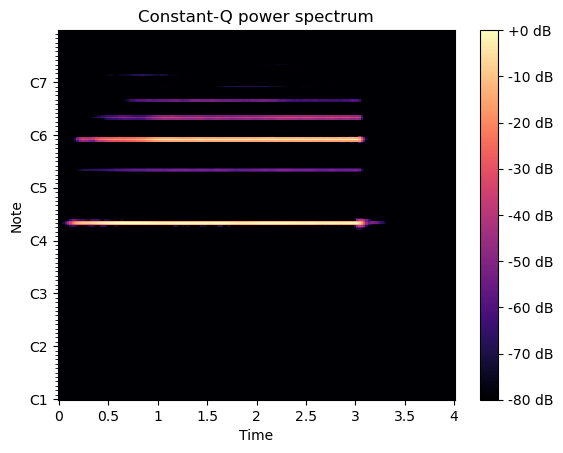

In [24]:
sr = 22050
hop_length = 512 
bins_per_octave = 36
n_bins = 252

# Plot the CQT feature
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(Y, ref=np.max),
                               sr=sr, hop_length=hop_length, bins_per_octave=bins_per_octave, x_axis='time', y_axis='cqt_note', ax=ax)
ax.set_title('Constant-Q power spectrum')
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.show()

In [25]:
Y = np.abs(train_features[6].cpu().numpy()) ** 2

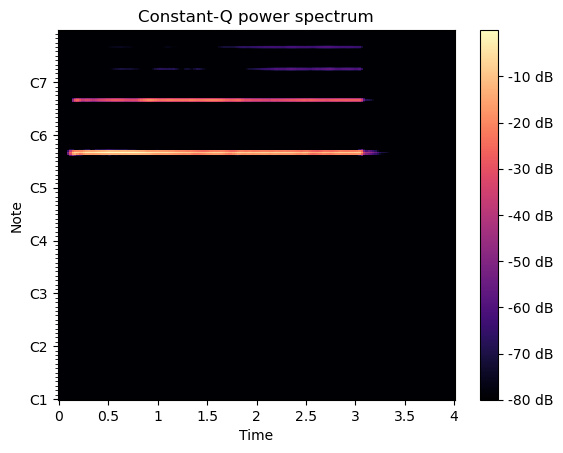

In [26]:
sr = 22050
hop_length = 512 
bins_per_octave = 36
n_bins = 252

# Plot the CQT feature
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(Y, ref=np.max),
                               sr=sr, hop_length=hop_length, bins_per_octave=bins_per_octave, x_axis='time', y_axis='cqt_note', ax=ax)
ax.set_title('Constant-Q power spectrum')
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.show()

## 2. plot a confusion matrix for the network predictions (predictions vs. true labels). Can you observe a pattern?

In [38]:
import torchvision.models as models

ModuleNotFoundError: No module named 'torch._custom_ops'

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder

In [28]:
model.eval()  
all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        features, labels = data
        outputs = model(torch.abs(features))
        _, preds = torch.max(outputs, 1)        
        all_preds.extend(preds.clone().detach().to(device))        
        numeric_labels = torch.abs(60 - labels[2])        
        all_labels.extend(numeric_labels.clone().detach().to(device))

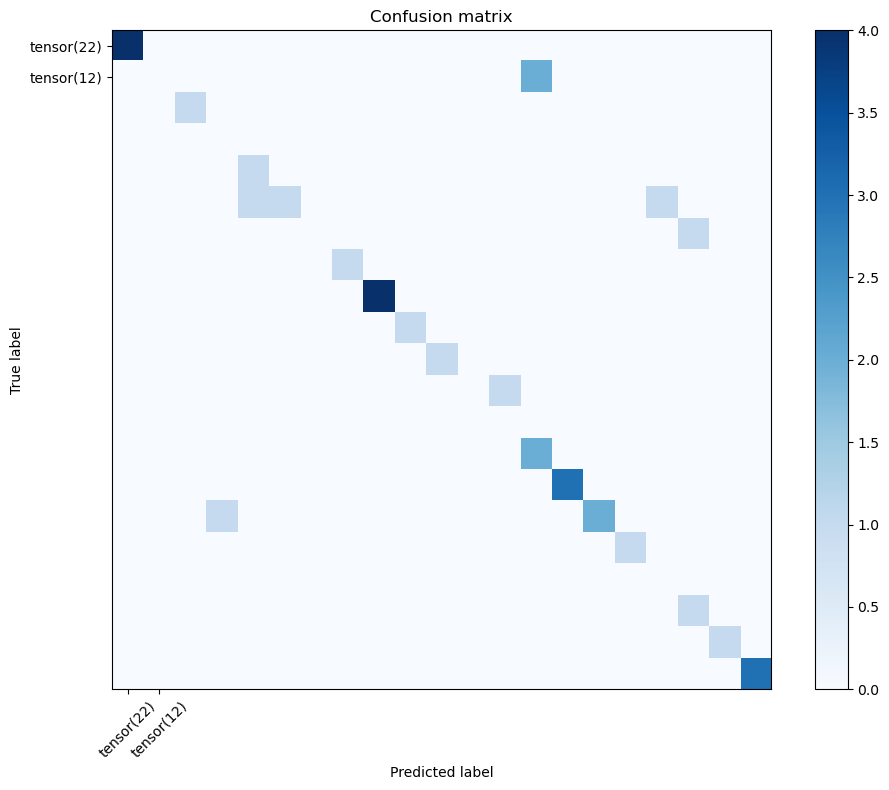

In [29]:
all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)
cm = confusion_matrix(all_labels_np, all_preds_np)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(len( torch.abs(60 - labels[2])))
plt.xticks(tick_marks,  torch.abs(60 - labels[2]), rotation=45)
plt.yticks(tick_marks,  torch.abs(60 - labels[2]))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## 3. play around with the learning rate - what influence does it have on the training?

1. Having too big of a learning rate (eg 0.1) : The loss is not reduced the same way as the given learning rate (0.01), the loss reduces very slowly and moreover increases after some point (probably jumped over the global minimum)
2. Having too small of a learning rate (eg 0.00001) : The loss is just as bad if not worse, the confusion matrix looks ugly, because its a flop

## 4. Instrument classifier 

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [31]:
unique_labels = ['CLA', 'OBO', 'PIA', 'VLC', 'VLN', 'TRP', 'FLU']
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(np.array(unique_labels).reshape(-1, 1))

OneHotEncoder(sparse_output=False)

In [32]:
unique_labels

['CLA', 'OBO', 'PIA', 'VLC', 'VLN', 'TRP', 'FLU']

In [33]:
class IntrumentNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1,10,(5,15))
        self.bn1 = nn.BatchNorm2d(10)
        self.pool1 = nn.MaxPool2d((3,7))
        
        self.conv2 = nn.Conv2d(10,3,(5,11)) 
        self.pool2 = nn.MaxPool2d((1,3))
        
        self.dense1 = nn.Linear(in_features = 3*78*4,
                                out_features=7)
        
        
        
    def forward(self, x):
        x = x[:,None,:,:]        
        y = self.pool1(F.relu(self.bn1(self.conv1(x))))
        y = self.pool2(F.relu(self.conv2(y)))
        logits = self.dense1(nn.Flatten()(y))   
        
        return logits

In [34]:
model = IntrumentNeuralNetwork().to(device)

summary(model, (252,173))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 10, 248, 159]             760
       BatchNorm2d-2         [-1, 10, 248, 159]              20
         MaxPool2d-3           [-1, 10, 82, 22]               0
            Conv2d-4            [-1, 3, 78, 12]           1,653
         MaxPool2d-5             [-1, 3, 78, 4]               0
            Linear-6                    [-1, 7]           6,559
Total params: 8,992
Trainable params: 8,992
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.17
Forward/backward pass size (MB): 6.18
Params size (MB): 0.03
Estimated Total Size (MB): 6.38
----------------------------------------------------------------


In [35]:
for epoch in range(20):
    epoch_start = time.time()
    running_loss = 0.069
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        features, labels = data
        # generate one-hot labels
        instrument_labels = labels[1]
        instrument_labels_np = np.array(instrument_labels).reshape(-1, 1)
        labels_oh = torch.tensor(encoder.transform(instrument_labels_np), dtype=torch.float32)
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(torch.abs(features).to(device))
        loss = criterion(outputs, labels_oh.to(device))
        loss.backward()
        optimizer.step()

    # print statistics
    running_loss += loss.item()
    print("Epoch %i, loss: %.8f, time[s]: %.5f"%(epoch, running_loss, time.time() - epoch_start))
    running_loss = 0.0

Epoch 0, loss: 1.96687292, time[s]: 1.79994
Epoch 1, loss: 2.14230203, time[s]: 1.58680
Epoch 2, loss: 2.07541274, time[s]: 1.65572
Epoch 3, loss: 1.94105184, time[s]: 1.70675
Epoch 4, loss: 2.02884805, time[s]: 1.72062
Epoch 5, loss: 2.21740817, time[s]: 1.69027
Epoch 6, loss: 2.09103918, time[s]: 1.88451
Epoch 7, loss: 1.98010623, time[s]: 1.69257
Epoch 8, loss: 1.95430648, time[s]: 1.44700
Epoch 9, loss: 1.94437766, time[s]: 1.63636
Epoch 10, loss: 1.98235571, time[s]: 1.56317
Epoch 11, loss: 1.95804440, time[s]: 1.97471
Epoch 12, loss: 2.04304575, time[s]: 1.78103
Epoch 13, loss: 1.99388062, time[s]: 1.81239
Epoch 14, loss: 1.72538864, time[s]: 1.72128
Epoch 15, loss: 2.10845494, time[s]: 1.63223
Epoch 16, loss: 2.21468162, time[s]: 1.68541
Epoch 17, loss: 2.19118642, time[s]: 1.84263
Epoch 18, loss: 1.90113329, time[s]: 1.91492
Epoch 19, loss: 1.96934044, time[s]: 1.73527


In [36]:
model.eval()  
all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        features, labels = data
        outputs = model(torch.abs(features))
        _, preds = torch.max(outputs, 1)        
        all_preds.extend(preds.clone().detach().to(device))        
        numeric_labels = torch.abs(60 - labels[2])        
        all_labels.extend(numeric_labels.clone().detach().to(device))

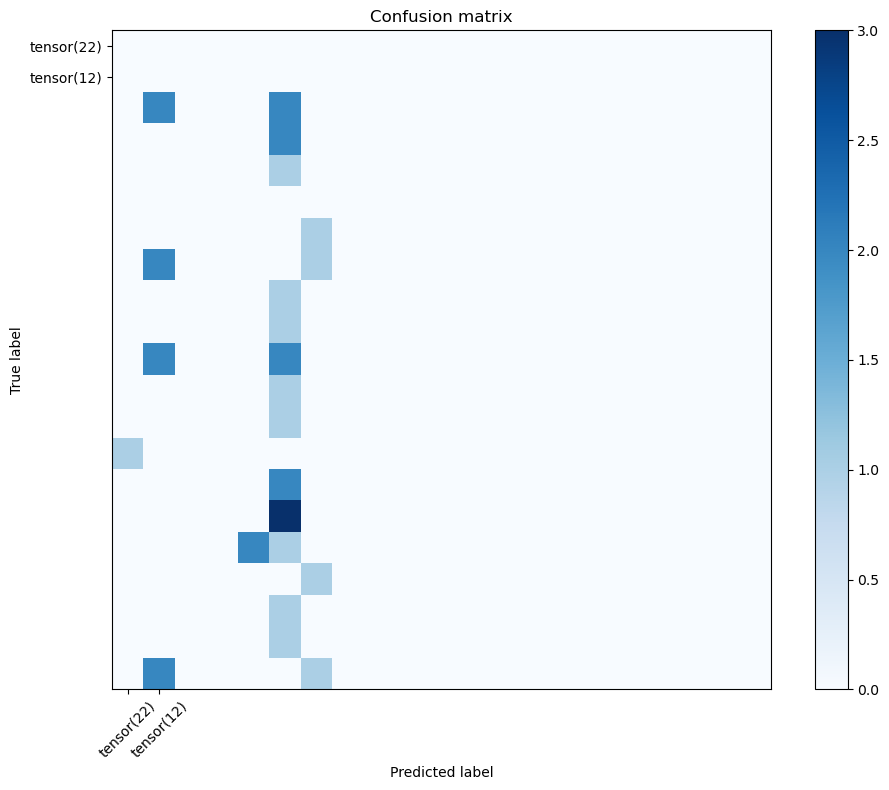

In [37]:
all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)
cm = confusion_matrix(all_labels_np, all_preds_np)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(len( torch.abs(60 - labels[2])))
plt.xticks(tick_marks,  torch.abs(60 - labels[2]), rotation=45)
plt.yticks(tick_marks,  torch.abs(60 - labels[2]))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## Questions

1. How can I play around with the learning rate without having to run all the cells from the top
2. 